# IQR outlier analysis and robust scaling
**Assigned member:** Dhananjana W. M. I. | **IT number:** IT25102551

**Group:** 26-MTR-IT2030-14 | **Dataset:** Letter Recognition

This notebook includes implementation, visible outputs, EDA, and interpretation. Run all cells and explain the decisions in your own words.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image

# Works when launched from the project root or the notebooks directory.
ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "pipeline.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "src" / "pipeline.py").exists(), "Start Jupyter inside the extracted project folder."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.pipeline import (FEATURES, SEED, load_raw, audit_and_clean, split_data,
                          outlier_audit, fit_transforms, verify, run)
raw = load_raw(ROOT)
clean, audit, removed = audit_and_clean(raw)
splits = split_data(clean)
train = splits["train"]
print("Raw:", raw.shape, "Clean:", clean.shape)
print("Partitions:", {name: len(part) for name, part in splits.items()})


Raw: (20000, 17) Clean: (18668, 17)
Partitions: {'train': 13067, 'validation': 2800, 'test': 2801}


## Shared inputs
The integrated pipeline generates the common plot artifacts. If they are absent, the following cell regenerates them. This notebook's technique implementation below remains independently executable.

In [2]:
if not (ROOT / "results/eda_visualizations/10_outlier_rates.png").exists():
    run(ROOT)

## Technique and justification
Fit 1.5 x IQR fences on the training partition to identify statistical extremes. Keep flagged records because they remain inside the source's valid range and can represent informative letter shapes. Create a RobustScaler alternative using medians and IQRs; it reduces the influence of extreme values on fitted centering/scaling parameters but does not delete or clip observations.

In [3]:
from sklearn.preprocessing import RobustScaler
x = train[FEATURES]
q1, q3 = x.quantile(0.25), x.quantile(0.75)
iqr = q3 - q1
flags = x.lt(q1 - 1.5 * iqr) | x.gt(q3 + 1.5 * iqr)
display(pd.DataFrame({"IQR": iqr, "flagged_count": flags.sum(), "flagged_percent": flags.mean() * 100}))
print("Rows flagged in any feature:", int(flags.any(axis=1).sum()))
robust = RobustScaler().fit(x)
robust_train = robust.transform(x)
robust_validation = robust.transform(splits["validation"][FEATURES])
robust_test = robust.transform(splits["test"][FEATURES])
display(pd.DataFrame(robust_train, columns=FEATURES).head())

,IQR,flagged_count,flagged_percent
x-box,2.0,346,2.647892
y-box,5.0,0,0.000000
width,2.0,290,2.219331
high,3.0,36,0.275503
onpix,3.0,197,1.507615
x-bar,2.0,511,3.910615
y-bar,3.0,235,1.798424
x2bar,3.0,413,3.160634
y2bar,3.0,72,0.551006
xybar,3.0,243,1.859646


Rows flagged in any feature: 5220


,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,-0.5,-0.2,0.0,-0.333333,-0.333333,1.0,-0.666667,-0.333333,1.333333,1.000000,-0.666667,0.5,-0.5,-1.0,0.666667,0.5
1,-1.0,0.0,-1.0,0.000000,-0.666667,3.0,-1.333333,1.333333,-0.333333,2.000000,-1.000000,1.5,-1.5,-1.0,-1.333333,0.0
2,0.0,-0.8,0.0,0.000000,0.000000,-0.5,0.333333,2.000000,1.333333,0.000000,0.333333,-1.0,0.0,0.0,0.000000,0.0
3,0.5,0.0,1.0,0.000000,1.333333,0.0,0.000000,0.666667,0.333333,-0.333333,0.000000,0.0,0.0,0.0,-0.333333,-0.5
4,-1.0,-0.8,-0.5,-1.000000,-0.333333,0.5,0.000000,0.000000,0.333333,0.666667,-0.666667,-1.5,-0.5,0.0,-0.666667,0.0


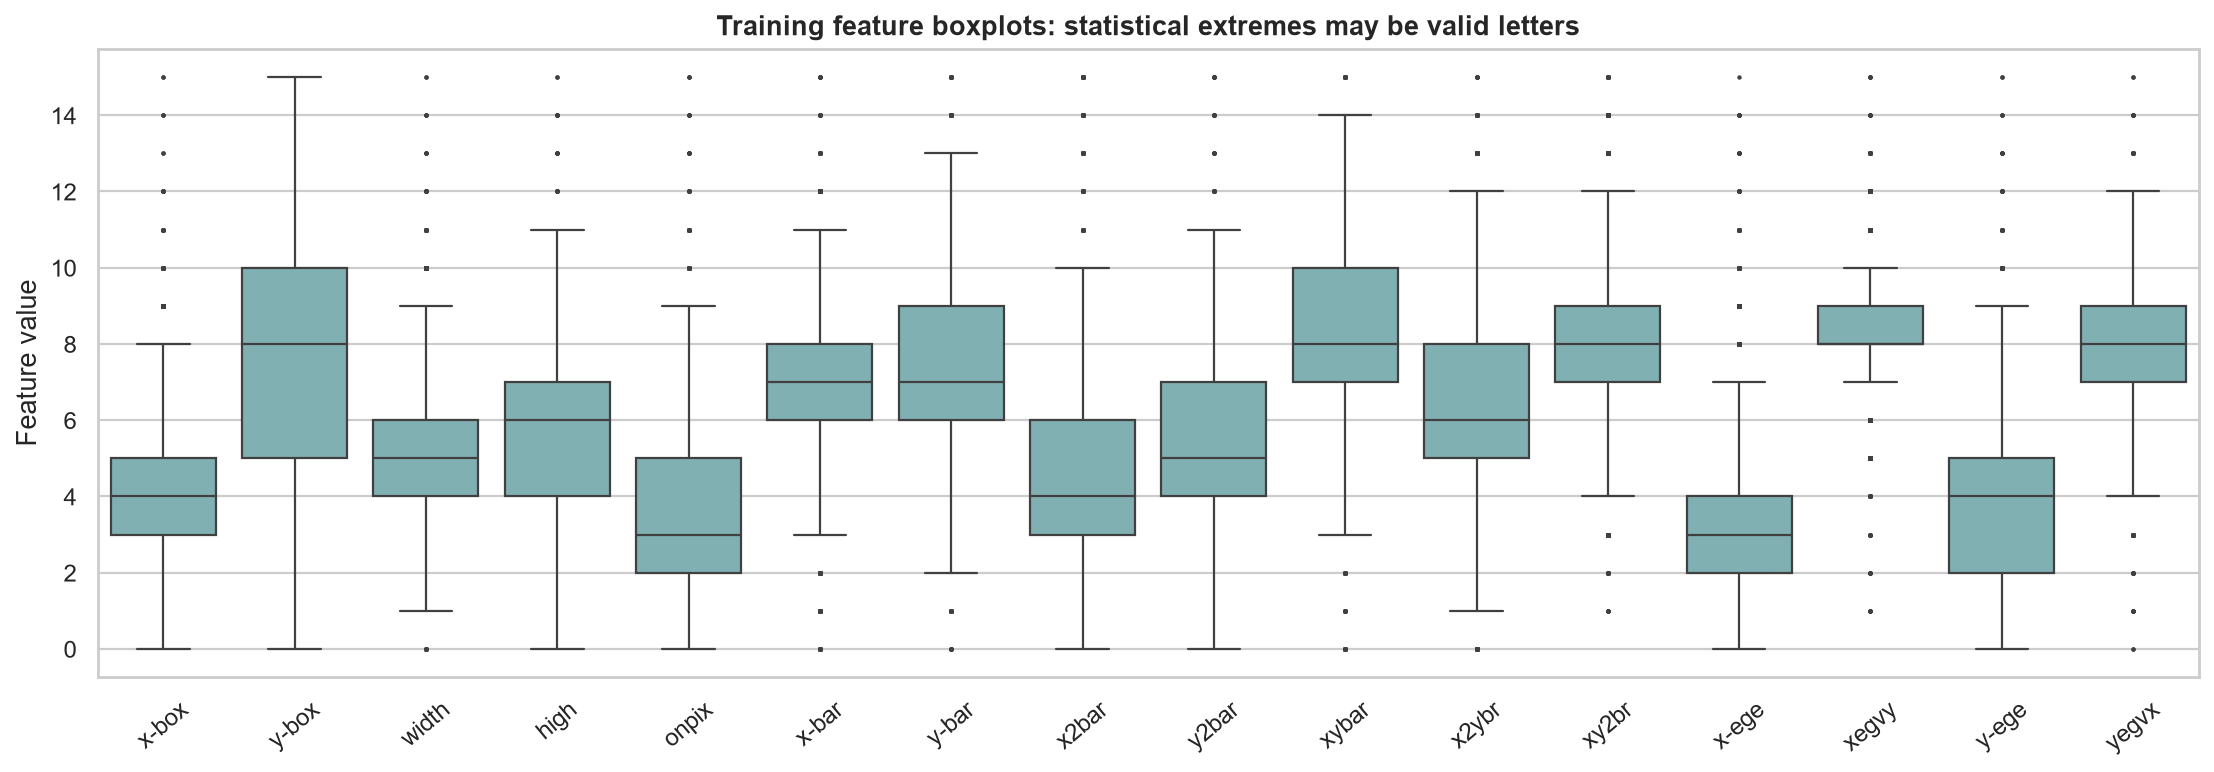

In [4]:
display(Image(filename=str(ROOT / "results/eda_visualizations/03_outlier_boxplots.png")))

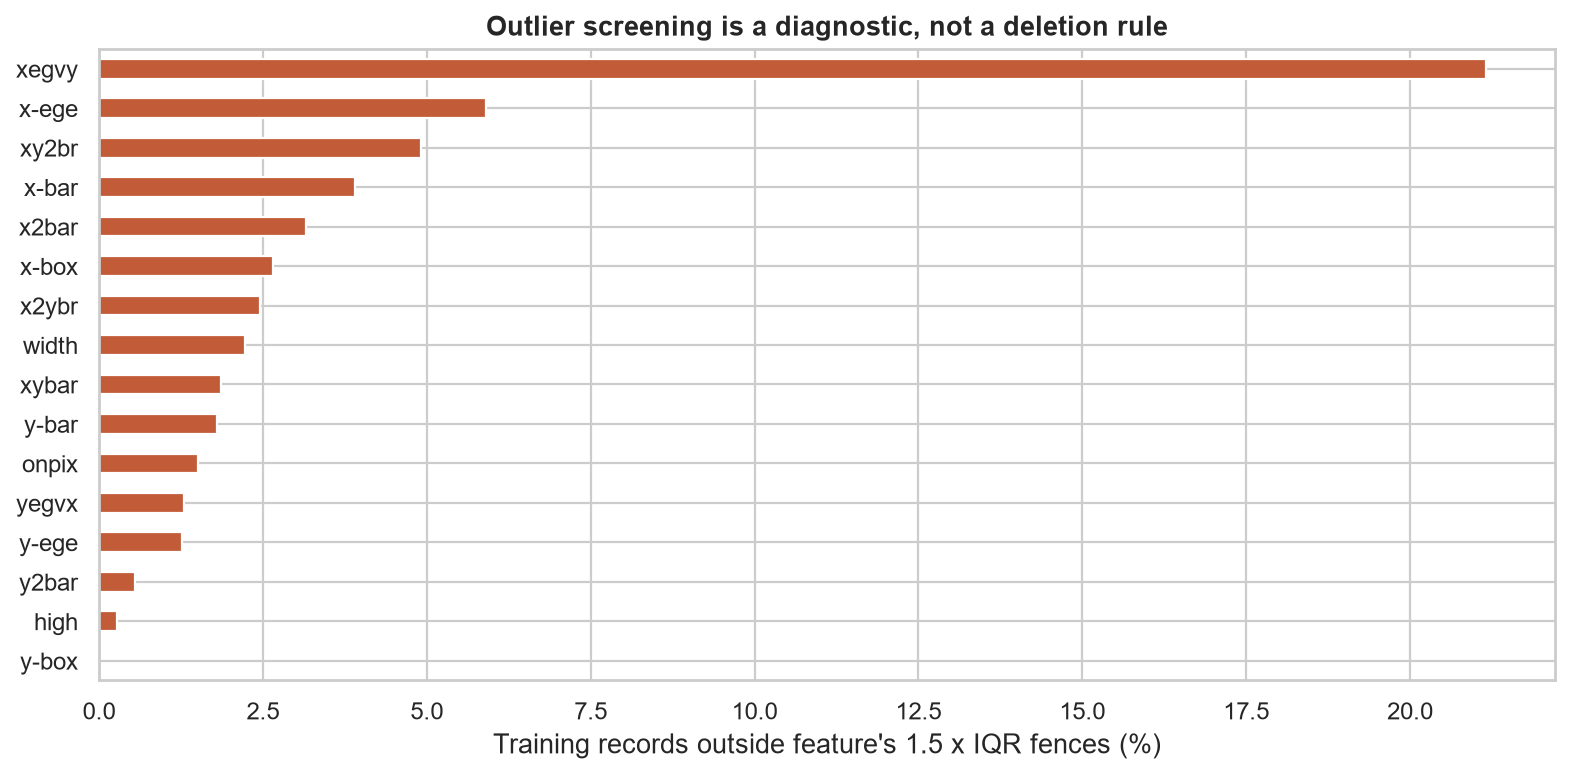

In [5]:
display(Image(filename=str(ROOT / "results/eda_visualizations/10_outlier_rates.png")))

## Interpretation
5,220 training records (39.95%) trigger at least one IQR flag. This is a multifeature screening rate, not an error rate. Removing every flagged row would discard a substantial number of valid observations.